# Synthetic Temporal Graph Notebook

This notebook is set up so that **only one cell needs to change** when you want to try a different synthetic dataset.

## Workflow
1. Edit the **generator cell** to create a new synthetic dataset.
2. Run the rest of the notebook unchanged.
3. The downstream cells will:
   - validate the generated data
   - visualize it
   - save it to JSON
   - load it through a PyTorch-compatible dataset class
   - show example timestep objects in the format your model expects

## Required output format from the generator cell
The generator cell must define a variable named `synthetic_data` with this structure:

```python
{
    "x_global": [[...], [...], ...],      # shape [num_nodes, embed_dim]
    "id_to_entity": {"0": "A0", ...},     # optional but recommended
    "id_to_rel": {"0": "rel1", "1": "rel2"},
    "timesteps": [
        {"edges": [{"src": 0, "dst": 10, "rel": 0}, ...]},
        {"edges": [...]},
        ...
    ]
}
```

Everything after the generator cell assumes only that format.
Each edge contains a rel_time field which is how long it has existed



In [28]:
# Imports and global config

from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Union

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import Tensor
from torch.utils.data import Dataset

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

OUT_DIR = Path("synthetic_data")
OUT_DIR.mkdir(exist_ok=True)

json_name = "2ent_5rel.json"

JSON_PATH = OUT_DIR / json_name

print(f"Saving outputs under: {OUT_DIR.resolve()}")

Saving outputs under: C:\Users\jaden\OneDrive\Yale Classes\CPSC 4520\Temporal_Knowledge_Graph_GNN\data_exploration\synthetic_data


## Replace only this next cell when you want a different synthetic process

In [29]:
# ADVANCED A-B SYNTHETIC DATA (MULTI-RELATION, STRUCTURED, NO NOISE)

import numpy as np

SEED = 7
rng = np.random.default_rng(SEED)

NUM_A = 14
NUM_B = 14
EMBED_DIM = 8
T = 250

P_START = 0.03

# durations per phase
CONTACT_STEPS = 2
NEGOTIATE_STEPS = 2
BONDED_STEPS = 5
STRAINED_STEPS = 2
RECOVERY_STEPS = 2

# relation mapping
id_to_rel = {
    0: "contact",
    1: "negotiate",
    2: "bonded",
    3: "strained",
    4: "recovery",
}

A_nodes = [f"A{i}" for i in range(NUM_A)]
B_nodes = [f"B{i}" for i in range(NUM_B)]
all_nodes = A_nodes + B_nodes

entity_to_id = {name: i for i, name in enumerate(all_nodes)}
id_to_entity = {i: name for name, i in entity_to_id.items()}

node_types = {entity_to_id[n]: n[0] for n in all_nodes}

x_global = rng.normal(size=(len(all_nodes), EMBED_DIM)).astype(np.float32)

# ----------------------------
# State encoding
# ----------------------------
# 0 = inactive
# 1-2 = contact
# 3-4 = negotiate
# 5-9 = bonded
# 10-11 = strained
# 12-13 = recovery

pair_state = np.zeros((NUM_A, NUM_B), dtype=np.int64)

timesteps = []
label_matrices = []

def state_to_rel_and_time(state):
    if state in (1, 2):
        return 0, state
    elif state in (3, 4):
        return 1, state - 2
    elif state in (5, 6, 7, 8, 9):
        return 2, state - 4
    elif state in (10, 11):
        return 3, state - 9
    elif state in (12, 13):
        return 4, state - 11
    else:
        return None, None


for t in range(T):
    edges = []

    rel_labels = np.full((NUM_A, NUM_B), -1, dtype=np.int64)
    rel_time_labels = np.zeros((NUM_A, NUM_B), dtype=np.float32)

    # -------- Emit edges --------
    for i in range(NUM_A):
        for j in range(NUM_B):
            state = pair_state[i, j]
            if state == 0:
                continue

            rel, rel_time = state_to_rel_and_time(state)

            src = entity_to_id[f"A{i}"]
            dst = entity_to_id[f"B{j}"]

            edges.append({
                "src": src,
                "dst": dst,
                "rel": rel,
                "rel_time": float(rel_time),
            })

            rel_labels[i, j] = rel
            rel_time_labels[i, j] = rel_time

    timesteps.append({"edges": edges})

    label_matrices.append({
        "rel_labels": rel_labels.tolist(),
        "rel_time": rel_time_labels.tolist(),
    })

    # -------- Advance state --------
    next_state = pair_state.copy()

    for i in range(NUM_A):
        for j in range(NUM_B):
            state = pair_state[i, j]

            if state == 0:
                if rng.random() < P_START:
                    next_state[i, j] = 1

            elif state < 13:
                next_state[i, j] = state + 1

            else:
                next_state[i, j] = 0

    pair_state = next_state


synthetic_data = {
    "x_global": x_global.tolist(),
    "id_to_entity": {str(k): v for k, v in id_to_entity.items()},
    "id_to_rel": {str(k): v for k, v in id_to_rel.items()},
    "node_types": {str(k): v for k, v in node_types.items()},
    "timesteps": timesteps,
    "label_matrices": label_matrices,
    "meta": {
        "seed": SEED,
        "num_A": NUM_A,
        "num_B": NUM_B,
        "embed_dim": EMBED_DIM,
        "T": T,
        "p_start": P_START,
        "process": {
            "contact": CONTACT_STEPS,
            "negotiate": NEGOTIATE_STEPS,
            "bonded": BONDED_STEPS,
            "strained": STRAINED_STEPS,
            "recovery": RECOVERY_STEPS,
        },
        "edge_relative_time_definition": "time spent in the current relation phase",
    },
}

print("Generated synthetic_data")
print(f"num_nodes = {len(synthetic_data['x_global'])}")
print(f"num_relations = {len(synthetic_data['id_to_rel'])}")
print(f"num_timesteps = {len(synthetic_data['timesteps'])}")
print(f"timestep 0 edges = {len(synthetic_data['timesteps'][0]['edges'])}")
print(f"timestep 10 edges = {len(synthetic_data['timesteps'][10]['edges'])}")

Generated synthetic_data
num_nodes = 28
num_relations = 5
num_timesteps = 250
timestep 0 edges = 0
timestep 10 edges = 44


In [30]:
# Validation and quick summary

required_keys = {"x_global", "id_to_rel", "timesteps"}
missing = required_keys - set(synthetic_data.keys())
if missing:
    raise ValueError(f"synthetic_data missing required keys: {missing}")

xg = np.array(synthetic_data["x_global"], dtype=np.float32)
if xg.ndim != 2:
    raise ValueError(f"x_global must be 2D, got shape {xg.shape}")

num_nodes, embed_dim = xg.shape
num_timesteps = len(synthetic_data["timesteps"])
num_relations = len(synthetic_data["id_to_rel"])

print("Validation passed")
print(f"x_global shape: {xg.shape}")
print(f"num_relations:  {num_relations}")
print(f"num_timesteps:  {num_timesteps}")

edge_counts = [len(step.get("edges", [])) for step in synthetic_data["timesteps"]]
print(f"edge count range: {min(edge_counts)} .. {max(edge_counts)}")

Validation passed
x_global shape: (28, 8)
num_relations:  5
num_timesteps:  250
edge count range: 0 .. 72


In [31]:
# Save synthetic data to JSON

with open(JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(synthetic_data, f, indent=2)

print(f"Saved JSON to: {JSON_PATH.resolve()}")

Saved JSON to: C:\Users\jaden\OneDrive\Yale Classes\CPSC 4520\Temporal_Knowledge_Graph_GNN\data_exploration\synthetic_data\2ent_5rel.json


In [32]:
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np


def plot_temporal_graphs_general(
    synthetic_data,
    timesteps=None,
    cols=3,
    figsize_per_plot=(7, 5),
    layout="spring",
    fixed_layout=True,
    active_only=True,
    show_node_labels=True,
    show_edge_labels=False,
    show_rel_time=False,
    node_size=800,
    font_size=8,
    seed=7,
    multipartite_key="node_types",
):
    """
    General visualization for temporal synthetic graph snapshots.

    Parameters
    ----------
    synthetic_data : dict
        Dataset JSON-like object with keys such as:
          - id_to_entity
          - id_to_rel
          - timesteps
          - optionally node_types
    timesteps : list[int] | None
        Which timesteps to plot. If None, plots all.
    cols : int
        Number of subplot columns.
    figsize_per_plot : tuple
        Size per subplot.
    layout : str
        One of: 'spring', 'kamada_kawai', 'shell', 'circular', 'multipartite'
    fixed_layout : bool
        If True, computes positions once on the union graph and reuses them.
        Strongly recommended for comparing timesteps.
    active_only : bool
        If True, only draw nodes active in that timestep.
    show_node_labels : bool
        Whether to draw node names.
    show_edge_labels : bool
        Whether to draw relation labels on edges.
    show_rel_time : bool
        If True and edge has 'rel_time', append it to edge label.
    node_size : int
        Node marker size.
    font_size : int
        Base font size.
    seed : int
        Random seed for layout reproducibility.
    multipartite_key : str
        Key in synthetic_data containing node grouping info. Example: "node_types".
    """

    id_to_entity = {int(k): v for k, v in synthetic_data["id_to_entity"].items()}
    id_to_rel = {int(k): v for k, v in synthetic_data["id_to_rel"].items()}
    steps = synthetic_data["timesteps"]

    if timesteps is None:
        timesteps = list(range(len(steps)))

    # Optional grouping info for multipartite layouts
    raw_groups = synthetic_data.get(multipartite_key, None)
    node_groups = None
    if raw_groups is not None:
        node_groups = {int(k): str(v) for k, v in raw_groups.items()}

    # Build union graph once for consistent layout and relation discovery
    union_graph = nx.DiGraph()
    union_graph.add_nodes_from(id_to_entity.keys())

    relation_ids_present = set()
    for step in steps:
        for e in step.get("edges", []):
            src = int(e["src"])
            dst = int(e["dst"])
            rel = int(e["rel"])
            union_graph.add_edge(src, dst)
            relation_ids_present.add(rel)

    relation_ids_present = sorted(relation_ids_present)

    # Node colors
    if node_groups is not None:
        unique_groups = sorted(set(node_groups.values()))
        group_cmap = cm.get_cmap("tab10", max(len(unique_groups), 1))
        group_to_color = {
            g: group_cmap(i) for i, g in enumerate(unique_groups)
        }
        node_color_map = {
            nid: group_to_color.get(node_groups.get(nid, "default"), (0.8, 0.8, 0.8, 1.0))
            for nid in id_to_entity
        }
    else:
        node_color_map = {nid: "#bdbdbd" for nid in id_to_entity}

    # Edge colors by relation
    rel_cmap = cm.get_cmap("tab20", max(len(relation_ids_present), 1))
    rel_to_color = {
        rel: rel_cmap(i) for i, rel in enumerate(relation_ids_present)
    }

    def compute_positions(G):
        if layout == "spring":
            return nx.spring_layout(G, seed=seed)
        elif layout == "kamada_kawai":
            return nx.kamada_kawai_layout(G)
        elif layout == "circular":
            return nx.circular_layout(G)
        elif layout == "shell":
            if node_groups is not None:
                unique_groups = sorted(set(node_groups.values()))
                shells = []
                for g in unique_groups:
                    shell = [nid for nid in sorted(G.nodes()) if node_groups.get(nid) == g]
                    if shell:
                        shells.append(shell)
                if shells:
                    return nx.shell_layout(G, shells)
            return nx.shell_layout(G)
        elif layout == "multipartite":
            if node_groups is None:
                raise ValueError(
                    "layout='multipartite' requires synthetic_data['node_types'] "
                    "or another grouping field."
                )
            H = G.copy()
            for nid in H.nodes():
                H.nodes[nid]["subset"] = node_groups.get(nid, "unknown")
            return nx.multipartite_layout(H, subset_key="subset")
        else:
            raise ValueError(
                f"Unknown layout '{layout}'. "
                f"Choose from spring, kamada_kawai, circular, shell, multipartite."
            )

    # Reuse one layout across snapshots if requested
    if fixed_layout:
        base_pos = compute_positions(union_graph)
    else:
        base_pos = None

    n = len(timesteps)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_per_plot[0], rows * figsize_per_plot[1]),
        squeeze=False,
    )
    axes = axes.flatten()

    for plot_idx, t in enumerate(timesteps):
        ax = axes[plot_idx]
        step = steps[t]

        G = nx.DiGraph()
        G.add_nodes_from(id_to_entity.keys())

        for e in step.get("edges", []):
            src = int(e["src"])
            dst = int(e["dst"])
            rel = int(e["rel"])
            rel_time = float(e.get("rel_time", 0.0))
            G.add_edge(src, dst, rel=rel, rel_time=rel_time)

        if active_only:
            active_nodes = sorted(set(u for u, _ in G.edges()) | set(v for _, v in G.edges()))
            H = G.subgraph(active_nodes).copy()
        else:
            H = G.copy()

        if len(H.nodes()) == 0:
            ax.set_title(f"Timestep {t} | no active edges")
            ax.axis("off")
            continue

        if fixed_layout:
            pos = {nid: base_pos[nid] for nid in H.nodes()}
        else:
            pos = compute_positions(H)

        # Draw nodes
        nx.draw_networkx_nodes(
            H,
            pos,
            node_color=[node_color_map.get(nid, "#bdbdbd") for nid in H.nodes()],
            node_size=node_size,
            edgecolors="black",
            linewidths=0.8,
            ax=ax,
        )

        if show_node_labels:
            nx.draw_networkx_labels(
                H,
                pos,
                labels={nid: id_to_entity[nid] for nid in H.nodes()},
                font_size=font_size,
                ax=ax,
            )

        # Draw relation groups separately
        for rel in relation_ids_present:
            rel_edges = [(u, v) for u, v, d in H.edges(data=True) if d["rel"] == rel]
            if not rel_edges:
                continue

            nx.draw_networkx_edges(
                H,
                pos,
                edgelist=rel_edges,
                edge_color=[rel_to_color[rel]],
                width=2.0,
                alpha=0.85,
                arrows=True,
                arrowsize=16,
                ax=ax,
            )

        if show_edge_labels:
            edge_labels = {}
            for u, v, d in H.edges(data=True):
                rel_name = id_to_rel.get(d["rel"], str(d["rel"]))
                if show_rel_time:
                    edge_labels[(u, v)] = f"{rel_name}\nrt={d['rel_time']:.1f}"
                else:
                    edge_labels[(u, v)] = rel_name

            nx.draw_networkx_edge_labels(
                H,
                pos,
                edge_labels=edge_labels,
                font_size=max(font_size - 1, 6),
                rotate=False,
                bbox={"alpha": 0.7, "color": "white", "pad": 0.15},
                ax=ax,
            )

        ax.set_title(f"Timestep {t} | edges={H.number_of_edges()}", fontsize=11)
        ax.axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    # Add relation legend once
    handles = []
    labels = []
    for rel in relation_ids_present:
        handles.append(
            plt.Line2D([0], [0], color=rel_to_color[rel], lw=2)
        )
        labels.append(id_to_rel.get(rel, str(rel)))

    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(len(handles), 6), frameon=False)

    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

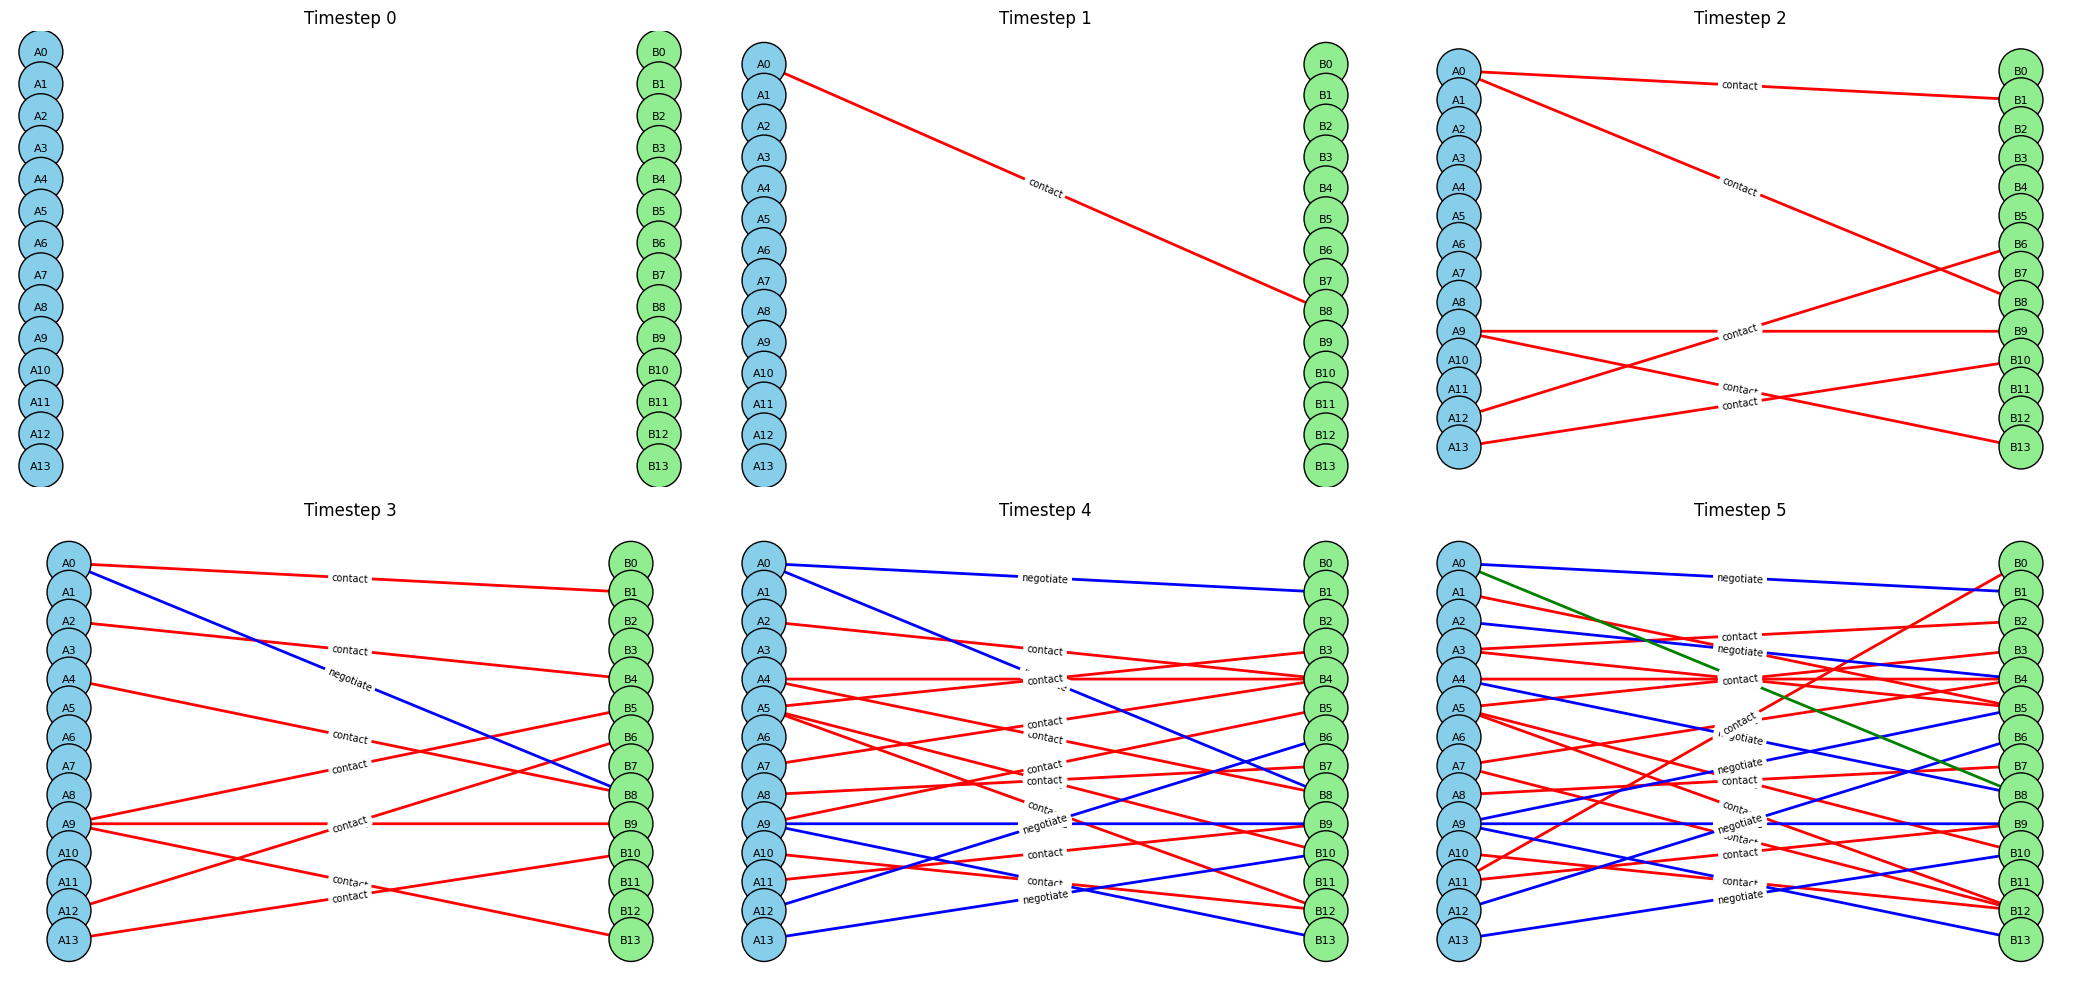

In [33]:
plot_temporal_graphs_fixed(synthetic_data, timesteps=[0, 1, 2, 3, 4, 5])